# 💾 The data: [cleaned_cholera_data.csv]()

In [20]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
from matplotlib.colors import ListedColormap
from scipy import stats
import scikit_posthocs as sp

In [21]:
# # Load the Dataset

# Read the csv file into a pandas DataFrame
df = pd.read_csv('cleaned_cholera_data.csv')

In [22]:
# View the first few rows
df.head(2)

,Country,Year,No. of Cases,No. of Deaths,Case Fatality Rate,WHO Region
0,Afghanistan,2016,677,5,0.738552,Eastern Mediterranean
1,Afghanistan,2015,58064,8,0.013778,Eastern Mediterranean


## 1. Descriptive Statistics

**Goals**:
- Establish the cumulative global prevalence(cases) and burden(deaths).
- Summarize the data's central tendency and spread  of Case Fatality Rates for different regions.
- Identify outlier years and regions of extreme epidemic activity.

**Columns of Interest**: `No. of Cases`, `No. of Deaths` and `Case Fatality Rate`

In [23]:
# Calculate the total global cases (the Prevalence)
total_global_cases = df['No. of Cases'].sum()

print(f"Total Cumulative Global Prevalence: {total_global_cases:,}")

Total Cumulative Global Prevalence: 9,194,780


In [24]:
# Calculate the total cases per region
regional_totals_c = df.groupby('WHO Region')['No. of Cases'].sum().sort_values(ascending=False)

print("\nContribution by Region:")
print(regional_totals_c)


Contribution by Region:
WHO Region
Africa                   3568261
South-East Asia          2248640
Americas                 2152299
Eastern Mediterranean     866758
Western Pacific           346955
Europe                     11867
Name: No. of Cases, dtype: int64


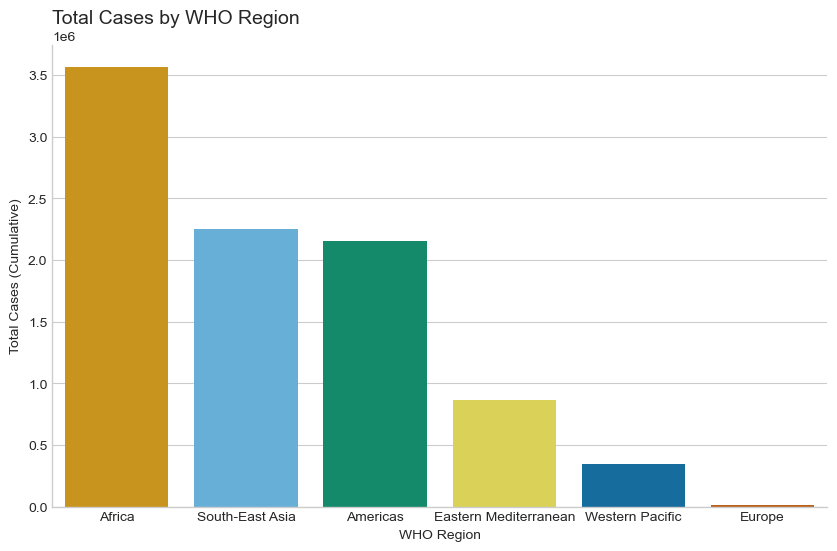

In [25]:
# Plot a bar chart to visualise total cases per region
plt.figure(figsize=(10, 6))

# Custom palette list
oi_palette = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00"]

sns.barplot(x=regional_totals_c.index, y=regional_totals_c.values, palette=oi_palette,
           hue = regional_totals_c.index )

sns.despine()

plt.title('Total Cases by WHO Region', loc='left', fontsize=14)
plt.ylabel('Total Cases (Cumulative)')
plt.show()

This chart shows us the region that regions that have had the most prevalence of cholera in the dataset.

Africa stands as the clear epicenter, recording over 3,5 milliion cumulative case. There is a significant step-down in volume as we move from Africa to South-East Asia and the Americas.
Europe is virtually unaffected in comparison.

In [26]:
# Calculate the total global deaths (the Burden)
total_global_deaths = df['No. of Deaths'].sum()

print(f"Total Cumulative Global Burden: {total_global_deaths:,}")

Total Cumulative Global Burden: 914,931


In [27]:
# Calculate the total deaths per region
regional_totals_d = df.groupby('WHO Region')['No. of Deaths'].sum().sort_values(ascending=False)

print("\nContribution by Region:")
print(regional_totals_d)


Contribution by Region:
WHO Region
South-East Asia          709969
Africa                   147446
Americas                  22805
Eastern Mediterranean     20573
Western Pacific           13862
Europe                      276
Name: No. of Deaths, dtype: int64


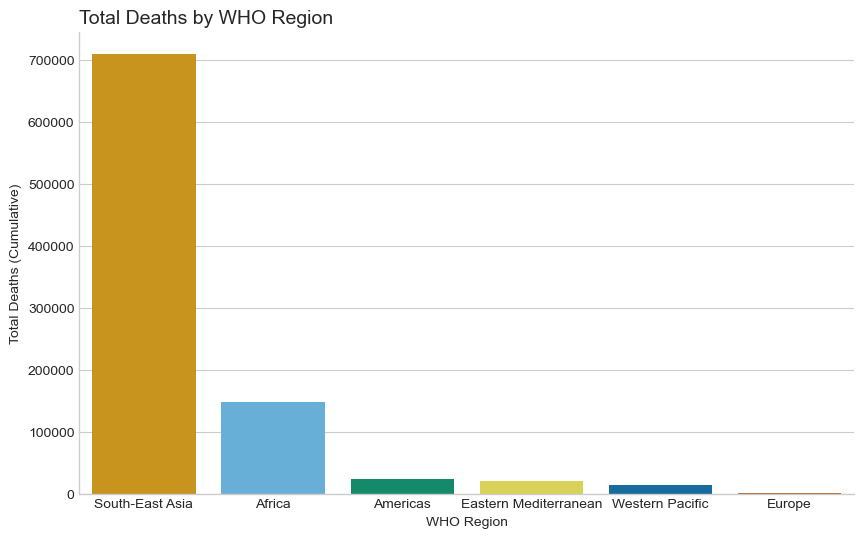

In [28]:
# Plot a bar chart to visualise total deaths per region
plt.figure(figsize=(10, 6))
sns.barplot(x=regional_totals_d.index, y=regional_totals_d.values, palette=oi_palette,
           hue = regional_totals_d.index )

sns.despine()

plt.title('Total Deaths by WHO Region', loc='left', fontsize=14)
plt.ylabel('Total Deaths (Cumulative)')
plt.show()

While the first chart showed where the infections have been more frequent, this visuals reveals where the disease has taken more lives.

South-East Asia has the highest number of cumulative deaths. The fact that the region with the second-highest case count(South-East Asia) has significantly more deaths than the region with most cases(Africa) is interesting. It suggests the Case Fatality Rate(CFR), which is the ration of deaths to cases is likely much higher in South-East Asia.

To truly understand the risk of a single person in these regions, we need to move pasr massive totals and look ast the Case Fatality Rate.

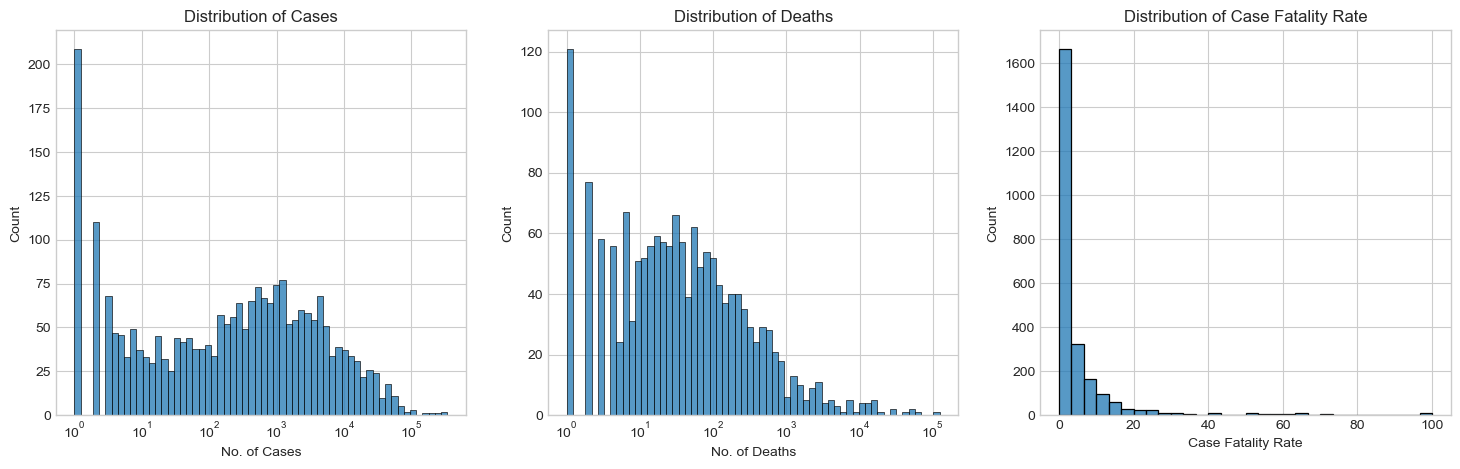

In [29]:
# Check the distribution of values in the columns of interest
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='No. of Cases', bins=60, kde=False, log_scale=(True, False), ax=axes[0])
axes[0].set_title('Distribution of Cases')

sns.histplot(data=df, x='No. of Deaths', bins=60, kde=False, log_scale=(True, False), ax=axes[1])
axes[1].set_title('Distribution of Deaths')

sns.histplot(data=df, x='Case Fatality Rate', bins=30, kde=False, ax=axes[2])
axes[2].set_title('Distribution of Case Fatality Rate')


plt.show()

- The distribution of data in the columns of interest are right-skewed and thus the mean is not a reliable typical value as it is pulled towards the outlier values.
-  Using median for central tendency and Interquatile Range(IQR) for spread are better fits because they are robust to outliers.

In [30]:
# Grouping and calculating  metrics for Case Fatality Rate
descriptive_stats = df.groupby('WHO Region')['Case Fatality Rate'].agg(
    Median='median',    # median
    Q1=lambda x: np.percentile(x, 25), # 1st Quartile
    Q3=lambda x: np.percentile(x, 75)  # 3rd Quartile
).reset_index()

# Calculate IQR (Spread) 
descriptive_stats['IQR'] = descriptive_stats['Q3'] - descriptive_stats['Q1']

In [31]:
print("--- Regional Descriptive Statistics ---\n")
print(descriptive_stats) 

--- Regional Descriptive Statistics ---

              WHO Region    Median        Q1         Q3        IQR
0                 Africa  3.191851  1.125622   7.265396   6.139774
1               Americas  0.534423  0.000000   1.646117   1.646117
2  Eastern Mediterranean  1.333333  0.000000   3.978370   3.978370
3                 Europe  0.000000  0.000000   0.000000   0.000000
4        South-East Asia  2.951822  0.500460  14.073084  13.572624
5        Western Pacific  0.267777  0.000000   2.794310   2.794310


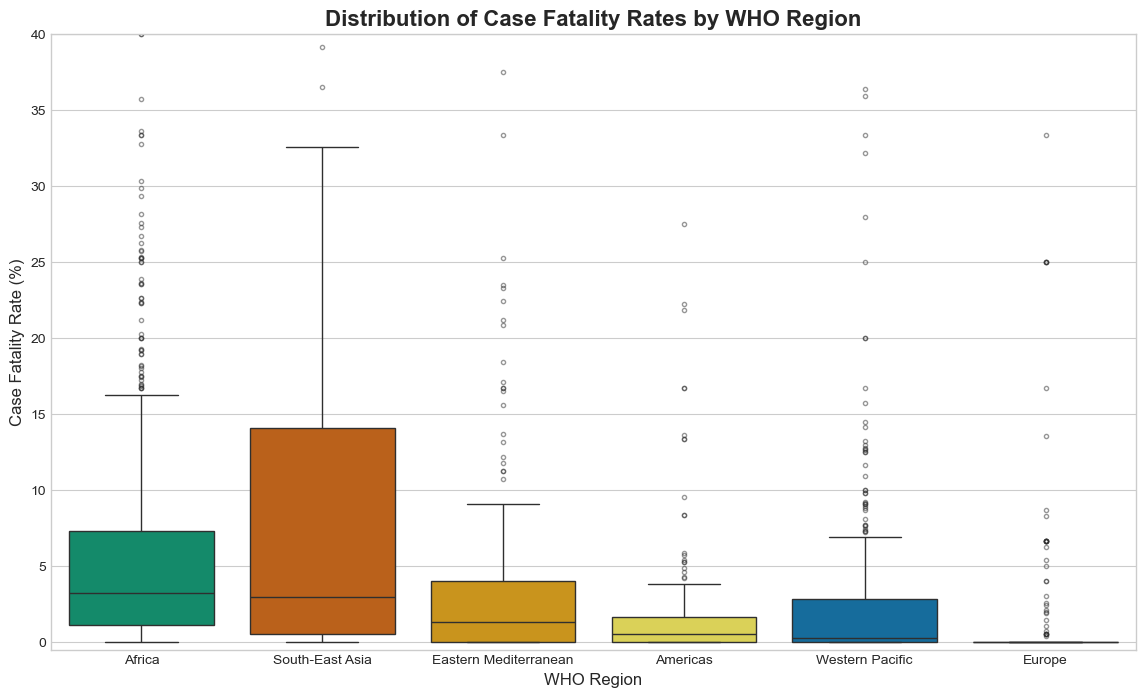

In [32]:
plt.figure(figsize=(14, 8))

# Sort regions by Median CFR so the chart tells a clear story from 'High to Low'
order = df.groupby('WHO Region')['Case Fatality Rate'].median().sort_values(ascending=False).index

sns.boxplot(data=df, 
            x='WHO Region', 
            y='Case Fatality Rate', 
            order=order, 
            palette=oi_palette,
            hue = 'WHO Region',
            flierprops={"marker": ".", "alpha": 0.5}) 


plt.title('Distribution of Case Fatality Rates by WHO Region', fontsize=16, fontweight='bold')
plt.xlabel('WHO Region', fontsize=12)
plt.ylabel('Case Fatality Rate (%)', fontsize=12)


# Optional: If outliers are so high they squash the boxes, cap the Y-axis to see the boxes better
plt.ylim(-0.5, 40) 

# plt.tight_layout()
plt.show()

**Interpretation**:
- The Box: Represents the middle 50% of CFR (the IQR).
- The Horizontal Line in the box: Marks the median (the "typical" fatality rate).
- The Whiskers: Extend to show the lowest and highest rates.
- Dots: Individual outbreak events with unusually high/low rates (outliers).
-------------------------------------------------------------------------------------------------
- Based on the plots, the median CFR of all the regions is below 5%. South-East Asia and Africa have not only the highest median rates, but also the widest boxes(IQR). This indicates that cholera in these regions has been more lethal as well as unstable, with some years having very low fatality while others have a very high fatality.

- The height of the South-East Asia box compared to Africa shows why despite having more Africa having more cumulative cases, South East Asia had more cumulative deaths.

- Europe and the Americas show both very low medians rates and a flat distributions, near 0%. This highlights that lethality is lower amd fairly consistent in these regions

In [33]:
# View Outlier years and regions where extreme events have taken place
columns = ['No. of Cases', 'No. of Deaths']

for column in columns:
    
    # Calculate Bounds
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR 
    upper_bound = Q3 + 1.5 * IQR

    # Filter Outliers
    outliers = df[df[column] > upper_bound]
    
    # Print Results 
    print(f"\n{'-'*10} {column} {'-'*10}")
    print(f"\nTop 10 Extreme Events:")
    print(outliers[['Country', 'WHO Region', 'Year', column]].sort_values(by=column, ascending=False).head(10))
    print("-" * 40)


---------- No. of Cases ----------

Top 10 Extreme Events:
           Country             WHO Region  Year  No. of Cases
897          Haiti               Americas  2011        340311
1730          Peru               Americas  1991        322562
1729          Peru               Americas  1992        242237
971          India        South-East Asia  1953        213225
898          Haiti               Americas  2010        179379
896          Haiti               Americas  2012        112076
1999  South Africa                 Africa  2001        106159
972          India        South-East Asia  1952        101493
973          India        South-East Asia  1951         86787
1971       Somalia  Eastern Mediterranean  2011         77636
----------------------------------------

---------- No. of Deaths ----------

Top 10 Extreme Events:
    Country       WHO Region  Year  No. of Deaths
971   India  South-East Asia  1953         124227
972   India  South-East Asia  1952          58252
966   

By examining the top 10 extreme events, we can identify:

- Extreme Case Events: The massive peaks in reported cases are largely attributed to the *2010–2012 crisis in Haiti* and the *1991–1992 outbreak in Peru*,both of these countries are in the Americas. Other significant events include *South Africa (2001)*, *Somalia (2011)* in Africa and *India (1950s) in South-East Asia*.

- Extreme Death Events: *India in the 1950s and 1960s* had a lot of deaths. India's 1953 outbreak stands out as the single deadliest event in the dataset, accounting for over 124,000 deaths in one year. This could also have pplayed a part in the high cumulative death count in South-East Asia.

## 2. Trend Analysis

By looking at the global trends, we can visualise when these extreme events took place as well as whether cholera is being handles better over time

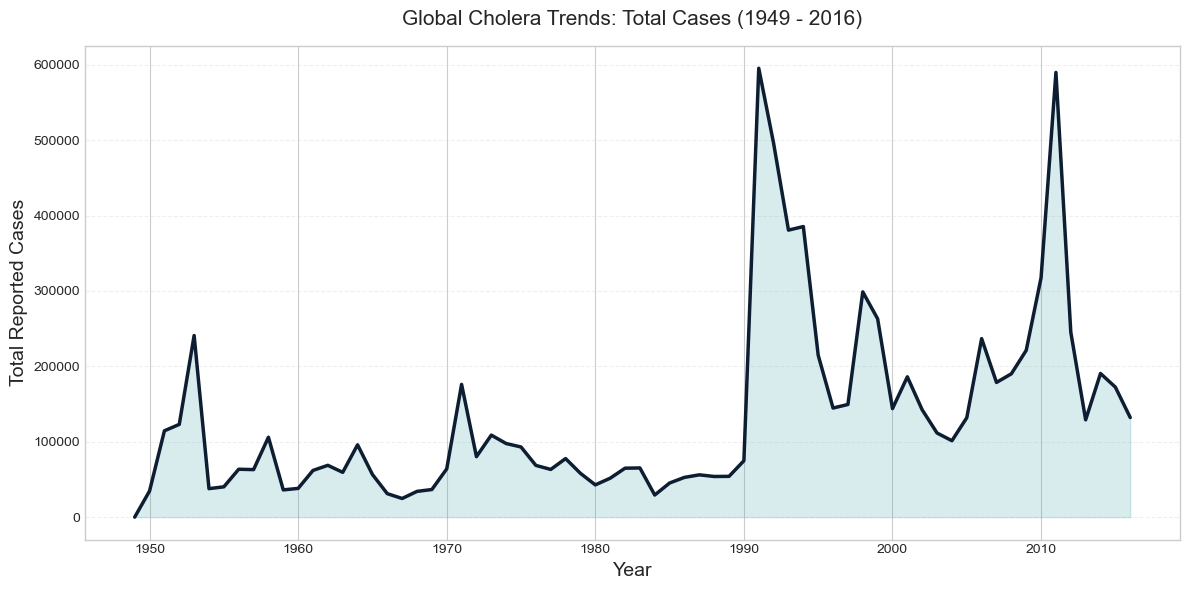

In [34]:
# Aggregate total global cases per year
yearly_trend = df.groupby('Year')['No. of Cases'].sum().reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(data=yearly_trend, x='Year', y='No. of Cases', color='#0e1e32', linewidth=2.5)
plt.fill_between(yearly_trend['Year'], yearly_trend['No. of Cases'], color='#3da4ab', alpha=0.2)

plt.title('Global Cholera Trends: Total Cases (1949 - 2016)', fontsize=15, pad=15)
plt.ylabel('Total Reported Cases', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

This plot shows thats cholera is far from being a disease of the past. We see two massive global spikes in the esrly 1990s and around 2011.These represent the resurgence of the disease in the Americas and major outbreaks in regions like Haiti and East Africa.

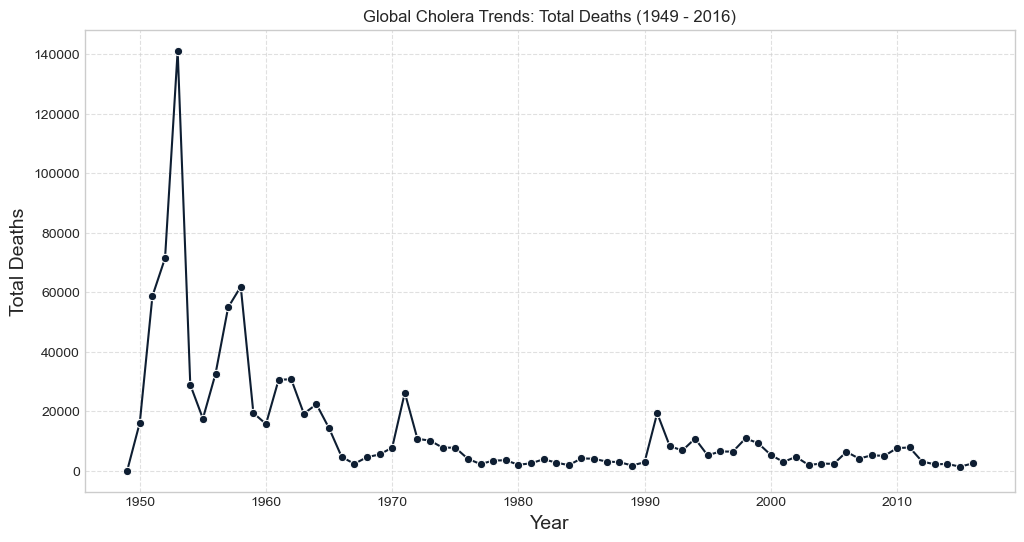

In [35]:
# Aggregate by year to see the total deaths worldwide
global_trends = df.groupby('Year')[['No. of Cases', 'No. of Deaths']].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=global_trends, x='Year', y='No. of Deaths', marker='o', color='#0e1e32')
plt.title('Global Cholera Trends: Total Deaths (1949 - 2016)')
plt.ylabel('Total Deaths', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

- The line charts show that cholera does not follow a steady downward path. Instead, the global history of the disease is a series of spikes.

- While theTotal Cases chart  shows huge peaks in 1991 and 2011, Deaths did not follow. In the  Total Deaths chart a massive spike  occurred in the 1950s.

- We might be are seeing more reported cases today due to better surveillance,  and less deaths because medical interventions have lowered the overall death toll compared to many years ago.

## 3. Inferential Statistics

The box plot earlier shows that there are differences in the Case Fatality Rates among the six WHO regions. Howeveer, we cannot rely on sight alone. This observation leads to the Inferential Statistics Phase, where we will prove if these regional disparities are statistically significant or just random fluctuations in the data.

### 3.1. Are there significant differences in Case Fatality Rates among all six WHO regions?

***Null Hypothesis(Ho)***: The default position(no significant difference). 

***Alternative Hypothesis***: There are differences. At least one WHO region has a significantly different CFR distribution than the others.


- *Groups*: We are comparing three or more independent groups **(The six WHO Regions)**

- *Test*: **Kruskal-Wallis Test**

    - Why?-  It is a non-parametric statistical test, meaning it does not assume the data follows a normal distribution. It  will serve as an alternative to a one-way ANOVA as assumption for that test (a normal distribution) is violated in this situation where the data is right-skewed due to the presence the outliers.

In [36]:
# Group the CFR values for each unique WHO Region
# Create a list of arrays(one for each region's cast fatality rates)
region_data = [group['Case Fatality Rate'] for name, group in df.groupby('WHO Region')]

In [37]:
# Run the Kruskal-Wallis Test
h_stat, p_val = stats.kruskal(*region_data)

In [38]:
# Print results
print(f"P-value: {p_val}\n")

if p_val < 0.05:
    print("Conclusion: There is an observed difference in Case Fatality Rates(Reject null hypothesis)")
else:
    print("Conclusion: There is no observed difference in Case Fatality Rates")

P-value: 1.0599699961117048e-121

Conclusion: There is an observed difference in Case Fatality Rates(Reject null hypothesis)


**Interpretation**
- Since the p-value is significantly lower than 0.05, we reject the null hypothesis. This confirms that cholera lethality is not uniform across the globe. At least one region is different.

- - The Kruskal-Wallis test shows  that the height difference in the boxplots showing the distibuton of case fatality rates by who region, are not due to luck.

### 3.2. Post-Hoc Test

- The Kruskall-Wallis Test revealed that at least one significant difference exist between the groups.

- The **Dunn's test** is a post-hoc test specifically designed to run after a significant Kruskal-Wallis result. It is necessary to  pinpoint  the specific groups that differ.

In [39]:
# Run Dunn's test with Bonferroni correction(to control for TYPE I errors)
dunn_results = sp.posthoc_dunn(
    df,
    val_col='Case Fatality Rate',
    group_col='WHO Region',
    p_adjust='bonferroni'
)

print("Dunn's Test P-Values (Adjusted):")
display(dunn_results)

Dunn's Test P-Values (Adjusted):


,Africa,Americas,Eastern Mediterranean,Europe,South-East Asia,Western Pacific
Africa,1.000000e+00,3.550453e-31,8.996797e-08,3.392001e-94,1.000000e+00,2.150960e-29
Americas,3.550453e-31,1.000000e+00,9.350124e-05,5.442397e-08,2.508821e-23,1.000000e+00
Eastern Mediterranean,8.996797e-08,9.350124e-05,1.000000e+00,9.624839e-25,1.524287e-06,2.045047e-02
Europe,3.392001e-94,5.442397e-08,9.624839e-25,1.000000e+00,1.996173e-63,3.153584e-16
South-East Asia,1.000000e+00,2.508821e-23,1.524287e-06,1.996173e-63,1.000000e+00,5.104758e-20
Western Pacific,2.150960e-29,1.000000e+00,2.045047e-02,3.153584e-16,5.104758e-20,1.000000e+00


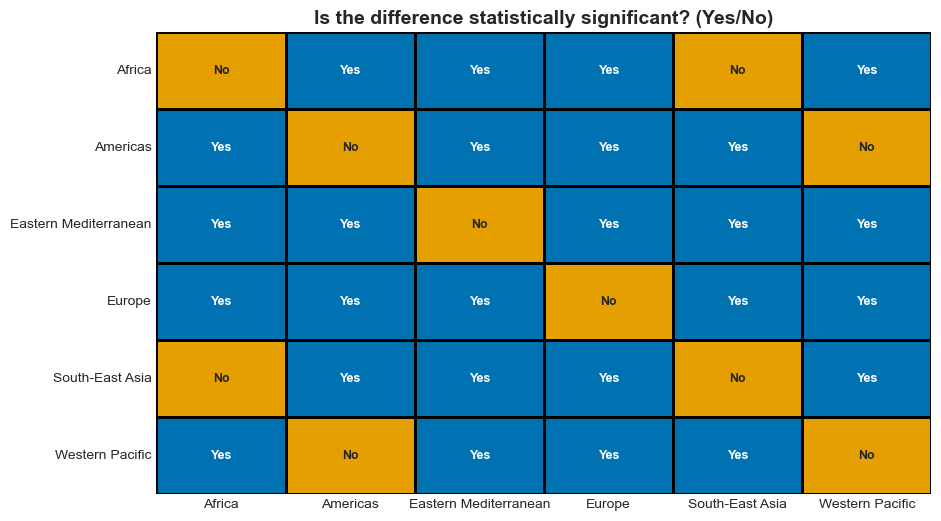

In [40]:
# Visulaise using a heatmap
significance_df = (dunn_results < 0.05)
yes_no_labels = (dunn_results < 0.05).replace({True: 'Yes', False: 'No'})

plt.figure(figsize=(10, 6))
colors = ListedColormap(["#E69F00", "#0072B2"])

sns.heatmap(
    significance_df.astype(int),
    annot=yes_no_labels,
    fmt="",
    cmap=colors,
    cbar=False,
    linewidths=1,
    linecolor='black',
    annot_kws={"size": 9, "weight": "bold"}
)

plt.title("Is the difference statistically significant? (Yes/No)",
         fontsize=14, fontweight='bold')
plt.show()

While the previous charts showed visula difference, this grid uses the Dunn’s Post-Hoc Test to provide mathematical proof of which regional disparities are actually significant.This matrix translates complex p-values into a clear "Yes/No" map, confirming where the differences in Case Fatality Rates (CFR) are mathematically undeniable

- The "No" result between Africa and South-East Asia is a major finding. It proves that these regions share a similar high-risk. Despite the difference in the number of cases and deaths, the lethality of cholera in these regions is statiscally indistinguishable.

- Interestingly, the Americas and Western Pacific also show no significance between them, suggesting the represent a middle tier of risk,different from the extreme lows of Europe or highs of Africa.

- The large number of "Yes"(Blue) boxes confirms that cholera risk is not uniform across the globe. Geography is a definitive factor in survival rate. 

## Conclusion

Through this analytical journey, we have moved Through this analytical journey, we have moved beyond raw numbers to uncover the structural inequality of global health:

- **The Incidence vs. The Burden**: While Africa carries the highest volume of cases, South-East Asia has historically faced the highest mortality risk. 

- **A Global Success Story**: Our trend analysis showed that despite global cases reaching record highs in the 1990s and 2010s, mortality rates have not followed. We are getting better at keeping people alive, even as the disease spreads.

- **Statistical Certainty**: Our inferential testing confirms that these regional differences are not random. The lethality gap between the Global North (Europe/Americas) and the Global South (Africa/SE Asia) is statistically significant and remains the primary challenge for future global health policy.